In [30]:
'''
- matplotlib
- seaborn
- plotly
'''

'\n- matplotlib\n- seaborn\n- plotly\n'

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
employee_name = ['Bob', 'Arthur', 'Bill', 'Dutch', 'Sadie']
salary = [20000, 30000, 10000, 40000, 35000]
bonus = [5000,10000,2000,15000,12345]

# Line Plot

C:\Users\dell\AppData\Local\Temp\ipykernel_3672\2862450848.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


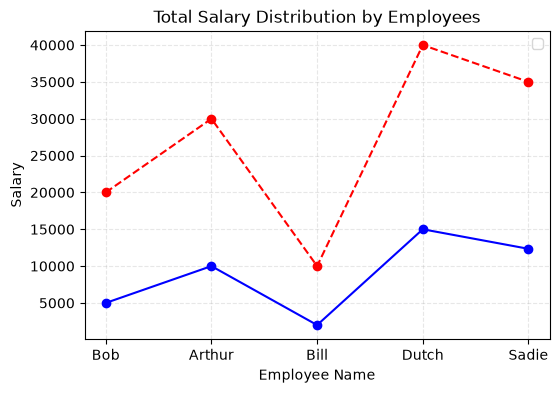

In [33]:
plt.figure(figsize=(6, 4)) # 600 x 400 pxl
plt.plot(employee_name, salary, color='red', marker='o', linestyle='--')
plt.plot(employee_name, bonus, color='blue', marker='o', linestyle='-')
plt.xlabel('Employee Name')
plt.ylabel('Salary')
plt.title('Total Salary Distribution by Employees')
plt.grid(alpha=0.3, linestyle='dashed')
plt.legend()
plt.show()

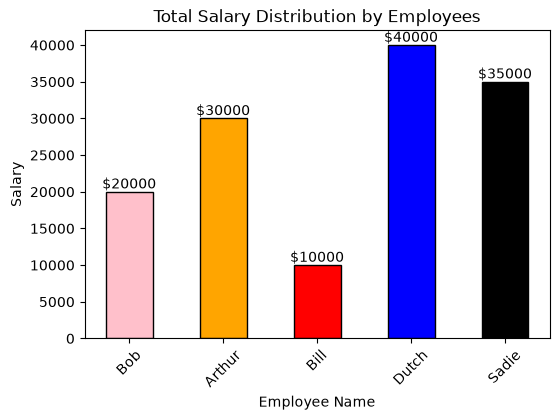

In [34]:
plt.figure(figsize=(6, 4)) # 600 x 400 pxl
plt.bar(employee_name, salary, color=['pink','Orange','Red','Blue','black'],width=0.5, edgecolor = 'black')
# plt.plot(employee_name, bonus, color='blue', marker='o', linestyle='-')
plt.xlabel('Employee Name')
plt.ylabel('Salary')
plt.title('Total Salary Distribution by Employees')
plt.xticks(rotation=45)
for idx,val in enumerate(salary):
    plt.text(idx,val,f'${val}', ha= 'center',va='bottom')
plt.show()

In [35]:
df = pd.read_csv("HR_Dataset Refresh.csv")
df.head()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2


In [36]:
perf_emp = df.groupby('PerformanceScore')['EmpID'].count().reset_index()
perf_emp

,PerformanceScore,EmpID
0,Exceeds,97
1,Fully Meets,454
2,Needs Improvement,18
3,PIP,13


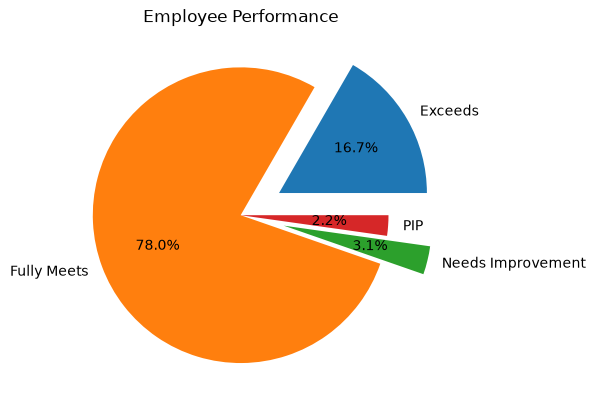

In [37]:
plt.pie(
perf_emp['EmpID'],
labels = perf_emp["PerformanceScore"],
autopct= "%1.1f%%",
explode = (0.3,0,0.3,0)
)
plt.title("Employee Performance")
plt.show()

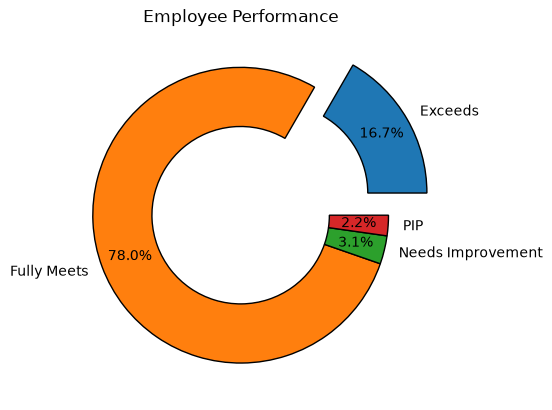

In [38]:
plt.pie(
perf_emp['EmpID'],
labels = perf_emp["PerformanceScore"],
autopct= "%1.1f%%",
#with edge properties
wedgeprops= {'width':0.4, 'edgecolor' : 'Black'},
pctdistance= 0.8,
explode= (0.3,0,0,0)
)
plt.title("Employee Performance")
plt.show()

# Scatter Plot

In [39]:
temp = pd.read_csv('Dataset/Dataset/temperature.csv')
temp.head()

,Temperature (°C),Humidity (%)
0,23.745401,57.186649
1,29.507143,66.765614
2,27.319939,64.034868
3,25.986585,60.921443
4,21.560186,49.099373


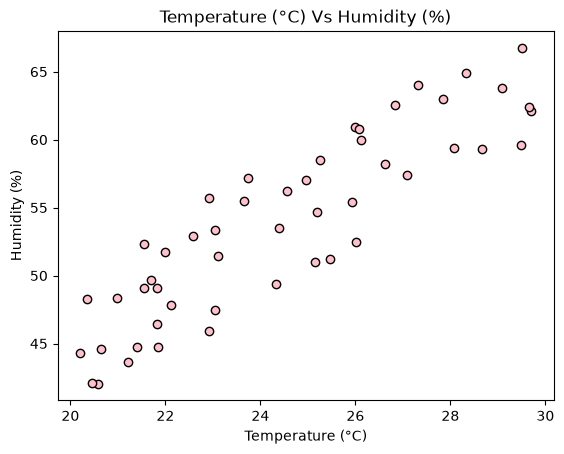

In [40]:
'''
-Both X-axis and Y-axis values must be continuous

'''
plt.scatter(temp['Temperature (°C)'],temp['Humidity (%)'], color = 'pink', edgecolors= 'Black')
plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (%)')
plt.title('Temperature (°C) Vs Humidity (%)')
plt.show()

# Correlaion Data

In [41]:
'''
-Pearson Correlation -> Data
-Spearman Correlation


-Only Integer/ Float
'''

'\n-Pearson Correlation -> Data\n-Spearman Correlation\n\n\n-Only Integer/ Float\n'

In [42]:
corr_columns = df.select_dtypes('int','float')
corr_columns = corr_columns.drop(columns= ['EmpID','MarriedID','GenderID','Zip'])
corr_columns

,MaritalStatusID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,Termd,PositionID,EmpSatisfaction,SpecialProjectsCount,DaysLateLast30,Absences
0,0,1,5,4,0,62506,0,19,5,0,0,1
1,1,5,3,3,0,104437,1,27,3,6,0,17
2,1,5,5,3,0,64955,1,20,3,0,0,3
3,1,1,5,3,0,64991,0,19,5,0,0,15
4,2,5,5,3,0,50825,1,19,4,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...
577,2,5,5,3,0,50825,1,19,4,0,0,2
578,0,1,5,4,0,57568,0,19,5,0,0,15
579,0,1,4,3,0,95660,0,24,3,4,0,19
580,4,1,5,3,0,59365,0,19,4,0,0,19


In [43]:
corr_data = corr_columns.corr()

<Axes: >

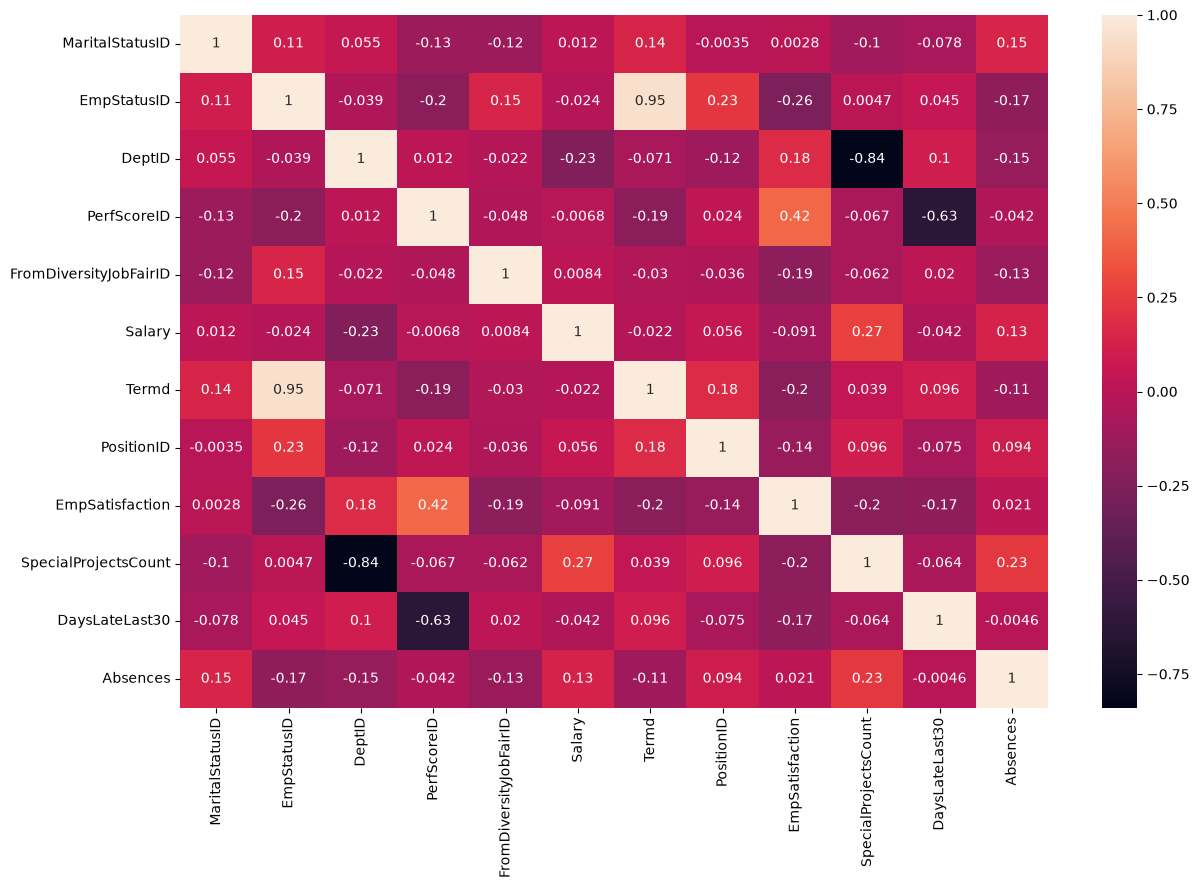

In [44]:
plt.figure(figsize=(14, 9))
sns.heatmap(corr_data, annot=True)

In [45]:
filter_salary = df[df['Salary'] < 81590]


In [46]:
salary = filter_salary['Salary']
mean_salary = salary.mean()
median_salary = salary.median()
salary_skew = salary.skew()
salary_skew

np.float64(0.03742636361706257)

# Histogram

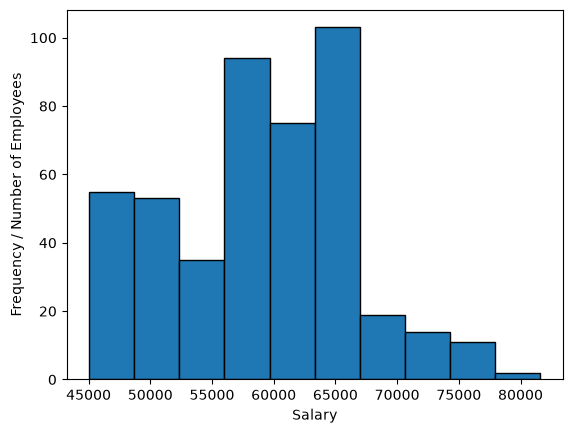

In [47]:
plt.hist(salary,edgecolor = 'Black')
plt.xlabel('Salary')
plt.ylabel('Frequency / Number of Employees')
plt.show()

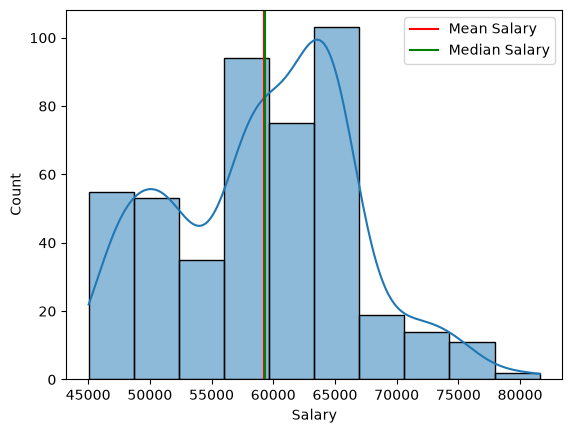

In [48]:
sns.histplot(salary, bins=10, kde = True)
plt.axvline(mean_salary, color = 'Red', label = 'Mean Salary')
plt.axvline(median_salary, color = 'Green', label = 'Median Salary')
plt.legend()
plt.show()

# Box Plot


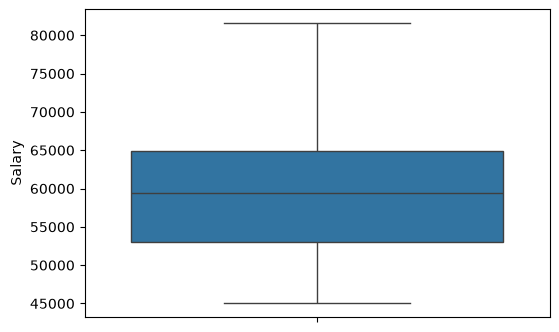

In [49]:
plt.figure(figsize=(6,4))
sns.boxplot(salary)
plt.show()

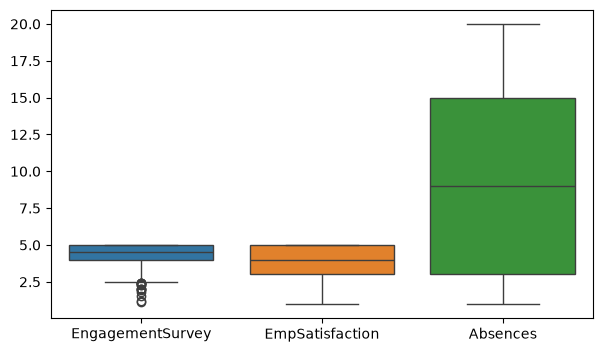

In [50]:
plt.figure(figsize=(7,4))
sns.boxplot(filter_salary[['EngagementSurvey','EmpSatisfaction','Absences']])
plt.show()

In [51]:
# Find total employees by each department nad gender

dep_gen = df.groupby(['Department', 'Gender'])['EmpID'].count().reset_index().rename(columns={"EmpID":"Total_Employees"})
dep_gen

,Department,Gender,Total_Employees
0,Admin Offices,F,6
1,Admin Offices,M,3
2,Executive Office,F,1
3,IT/IS,F,23
4,IT/IS,M,59
5,Production,F,274
6,Production,M,145
7,Sales,F,15
8,Sales,M,16
9,Software Engineering,F,35


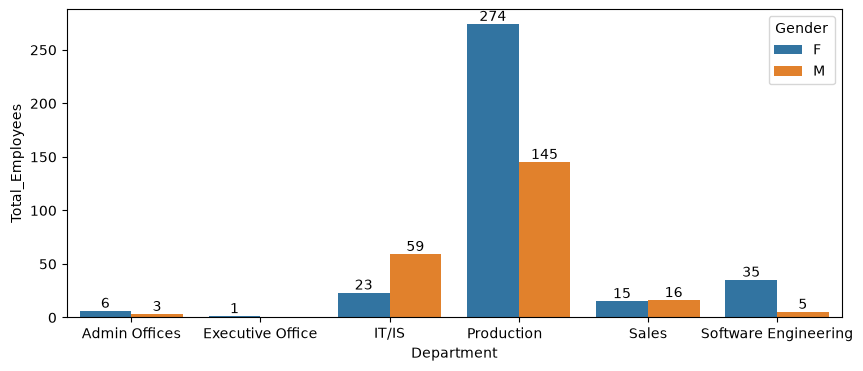

In [52]:
plt.figure(figsize=(10,4))
ax= sns.barplot(data=dep_gen, x = 'Department', y = 'Total_Employees', hue = 'Gender')
for container in ax.containers:
    plt.bar_label(container)

# Sub_Plots

In [53]:
dep_details = df.groupby('Department').agg(
    Total_Employee = ('EmpID','count'),
    Total_Salary = ('Salary','sum'),
    Total_Absences = ('Absences','sum'),
    Total_Projects=('SpecialProjectsCount','sum'),
 ).reset_index()

dep_details.columns

Index(['Department', 'Total_Employee', 'Total_Salary', 'Total_Absences',
       'Total_Projects'],
      dtype='str')

In [ ]:
def formatValue(val):
    if abs(val)>= 1e9:
        return f'{val/1e9:,.2f}B'
    
    elif abs(val)>= 1e6:
            return f'{val/1e6:,.2f}M'
    elif abs(val)>= 1e3:
            return f'{val/1e3:,.2f}K'
    else: return f'{val}'

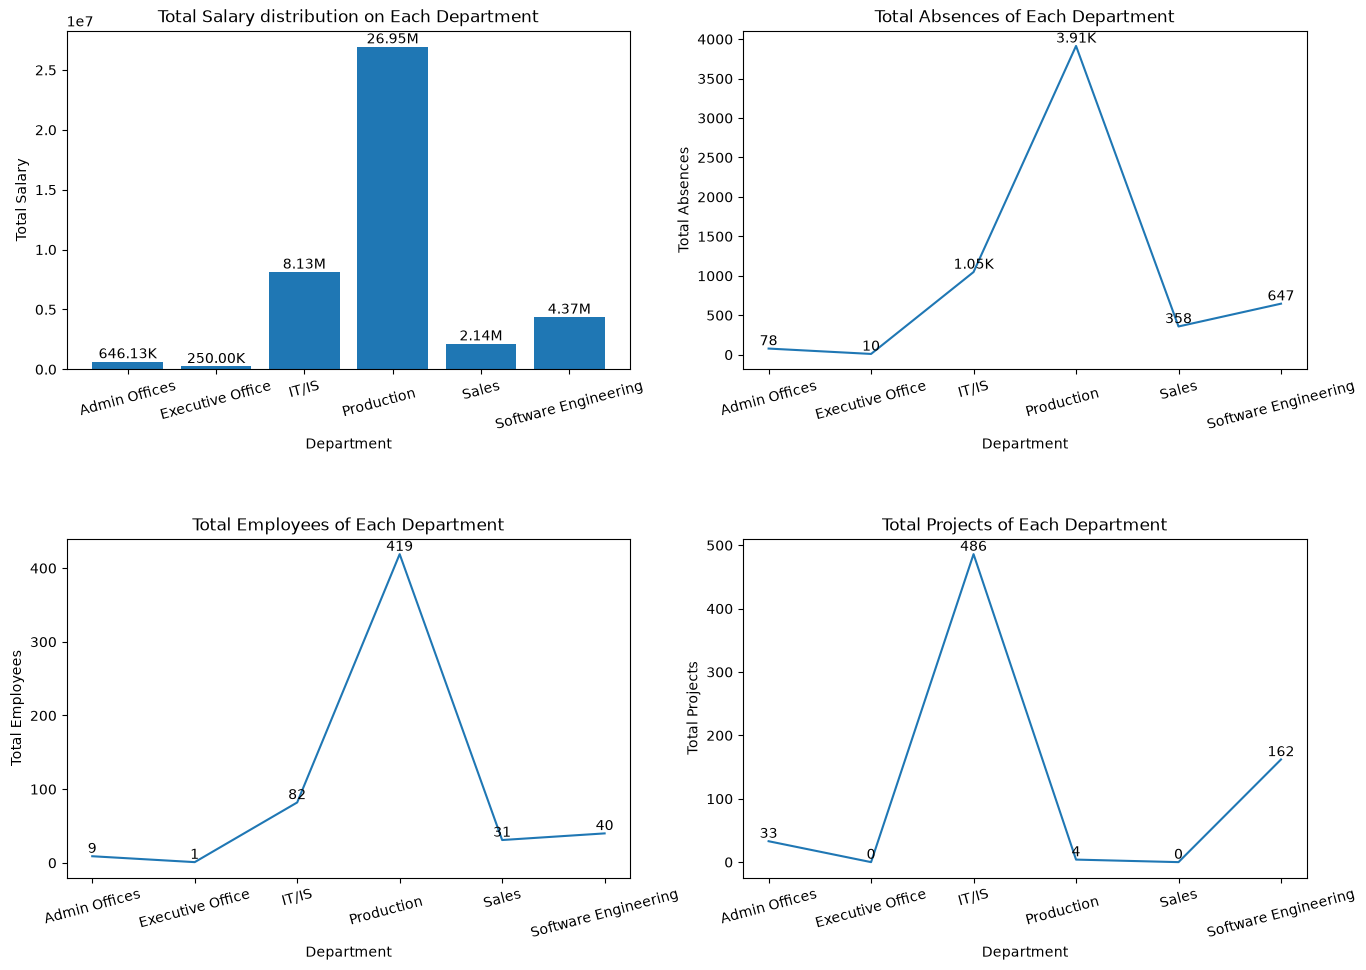

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
plt.subplots_adjust(hspace=0.5)

ax1 = axes[0, 0]
ax1.bar(dep_details['Department'], dep_details['Total_Salary'])
ax1.set_xlabel('Department')
ax1.set_ylabel('Total Salary')
ax1.set_title('Total Salary distribution on Each Department')
ax1.tick_params(axis='x', rotation=15)

for idx, val in enumerate(dep_details['Total_Salary']):
    formatted_val = formatValue(val)
    ax1.text(idx, val, str(formatted_val), ha='center', va='bottom')


ax2 = axes[0, 1]
ax2.plot(dep_details['Department'], dep_details['Total_Absences'])
ax2.set_xlabel('Department')
ax2.set_ylabel('Total Absences')
ax2.set_title('Total Absences of Each Department')
ax2.tick_params(axis='x', rotation=15)
for idx, val in enumerate(dep_details['Total_Absences']):
    formatted_val = formatValue(val)
    ax2.text(idx, val, str(formatted_val), ha='center', va='bottom')


ax3 = axes[1,0]
ax3.plot(dep_details['Department'], dep_details['Total_Employee'])
ax3.set_xlabel('Department')
ax3.set_ylabel('Total Employees')
ax3.set_title('Total Employees of Each Department')
ax3.tick_params(axis='x', rotation=15)
for idx, val in enumerate(dep_details['Total_Employee']):
    formatted_val = formatValue(val)
    ax3.text(idx, val, str(val), ha='center', va='bottom')


ax4 = axes[1,1]
ax4.plot(dep_details['Department'], dep_details['Total_Projects'])
ax4.set_xlabel('Department')
ax4.set_ylabel('Total Projects')
ax4.set_title('Total Projects of Each Department')
ax4.tick_params(axis='x', rotation=15)
for idx, val in enumerate(dep_details['Total_Projects']):
    formatted_val = formatValue(val)
    ax4.text(idx, val, str(formatted_val), ha='center', va='bottom')

plt.show()